# TP SVM


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ifri_mini_ml_lib.classification.svm import SVM
from ifri_mini_ml_lib.metrics.classification import accuracy, confusion_matrix, f1_score, precision, recall
from ifri_mini_ml_lib.preprocessing.dimensionality_reduction import PCA
from ifri_mini_ml_lib.preprocessing.preparation import DataSplitter, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

## Banknote Authentication

Classification binaire avec un SVM linéaire.

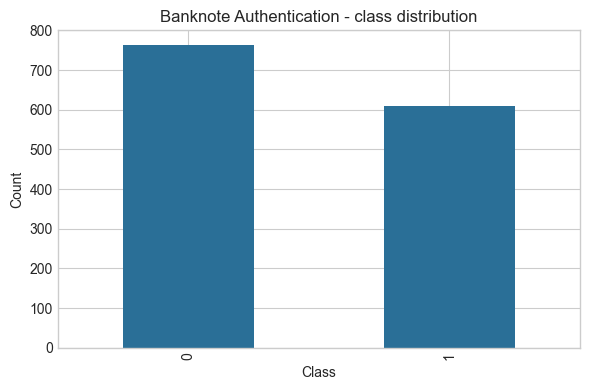

In [2]:
banknote_path = r"D:\ifri_mini_ml_lib\ifri_mini_ml_lib\classification\banknote+authentication\data_banknote_authentication.txt"

banknote_df = pd.read_csv(
    banknote_path,
    header=None,
    names=["variance", "skewness", "curtosis", "entropy", "class"],
)

X_banknote = banknote_df.drop(columns="class")
y_banknote = banknote_df["class"]

fig, ax = plt.subplots(figsize=(6, 4))
y_banknote.value_counts().sort_index().plot(kind="bar", color="#2a6f97", ax=ax)
ax.set_title("Banknote Authentication - class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [3]:
X_banknote.head()

,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [4]:
banknote_df = pd.read_csv(
    banknote_path,
    header=None,
    names=["variance", "skewness", "curtosis", "entropy", "class"],
)

X_banknote = banknote_df.drop(columns="class")
y_banknote = banknote_df["class"]


splitter = DataSplitter(seed=42)
Xb_train, Xb_test, yb_train, yb_test = splitter.stratified_train_test_split(
    X_banknote,
    y_banknote,
    test_size=0.2,
)


In [5]:
scaler = StandardScaler()
Xb_train_scaled = scaler.fit_transform(Xb_train)
Xb_test_scaled = scaler.transform(Xb_test)

banknote_svm = SVM(kernel="linear", C=1.0, max_iter=2000, tol=1e-4, random_state=42)
banknote_svm.fit(Xb_train_scaled, yb_train)
yb_pred = banknote_svm.predict(Xb_test_scaled)

print("Banknote Authentication - Linear SVM")
print(f"Accuracy: {accuracy(yb_test, yb_pred):.4f}")
print(f"Precision: {precision(yb_test, yb_pred, positive_class=1):.4f}")
print(f"Recall: {recall(yb_test, yb_pred, positive_class=1):.4f}")
print(f"F1-score: {f1_score(yb_test, yb_pred, positive_class=1):.4f}")

Banknote Authentication - Linear SVM
Accuracy: 0.8577
Precision: 1.0000
Recall: 0.6803
F1-score: 0.8098


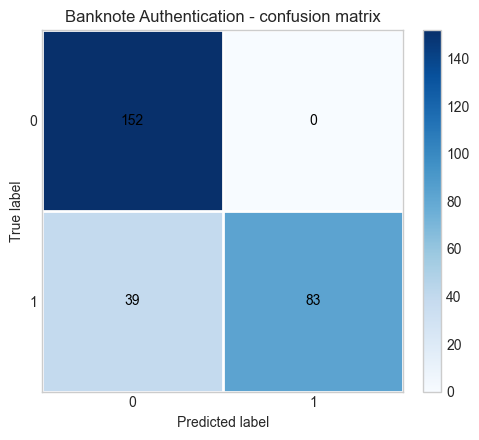

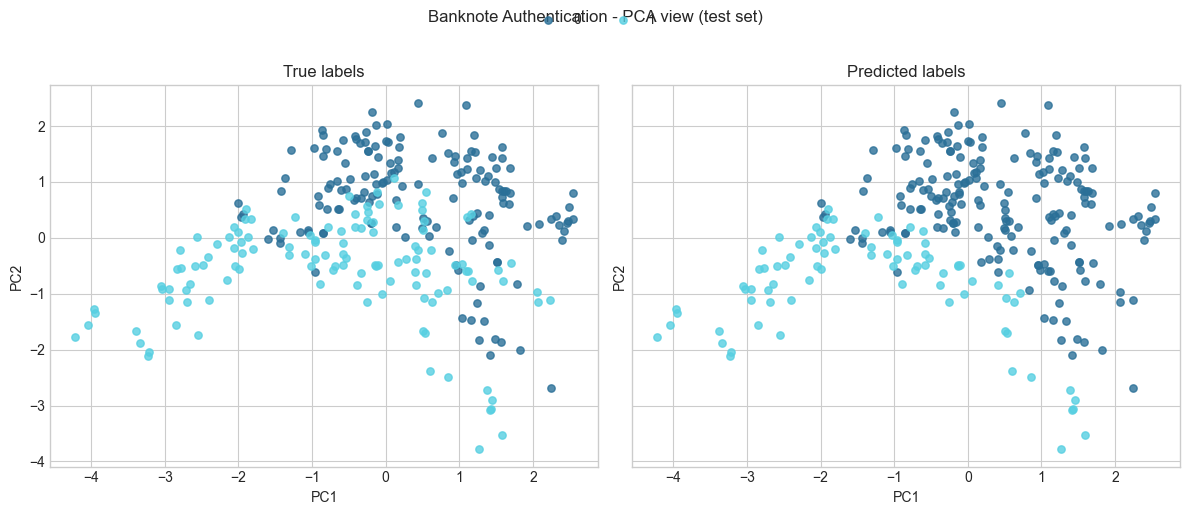

In [6]:


labels = [0, 1]
cm_dict = confusion_matrix(yb_test, yb_pred, classes=labels)
cm = np.array([[cm_dict[true_label][pred_label] for pred_label in labels] for true_label in labels])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
image = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.set_title("Banknote Authentication - confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.grid(False)
ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

pca = PCA(n_component=2)
pca.fit(np.asarray(Xb_train_scaled))
Xb_test_2d = pca.transform(np.asarray(Xb_test_scaled))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
colors = {0: "#2a6f97", 1: "#56cfe1"}
for cls in labels:
    mask_true = np.asarray(yb_test) == cls
    mask_pred = np.asarray(yb_pred) == cls
    axes[0].scatter(Xb_test_2d[mask_true, 0], Xb_test_2d[mask_true, 1], s=28, alpha=0.8, color=colors[cls], label=str(cls))
    axes[1].scatter(Xb_test_2d[mask_pred, 0], Xb_test_2d[mask_pred, 1], s=28, alpha=0.8, color=colors[cls], label=str(cls))

axes[0].set_title("True labels")
axes[1].set_title("Predicted labels")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("Banknote Authentication - PCA view (test set)", y=1.02)
plt.tight_layout()
plt.show()

## WineQT

Qualité regroupée en 3 classes: low (0 à 3), medium (4 à 6), high (7 à 9).

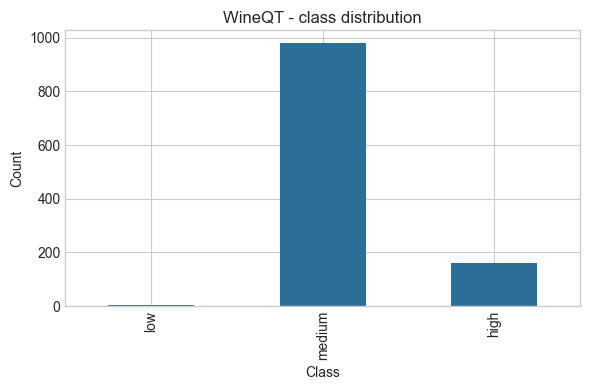

In [26]:
wine_path = r"D:\ifri_mini_ml_lib\ifri_mini_ml_lib\classification\WineQT.csv"
wine_df = pd.read_csv(wine_path)
X_wine = wine_df.drop(columns=["quality"])

wine_df["target"] = pd.cut(
    wine_df["quality"],
    bins=[0, 3, 6, 9],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

# définir explicitement l'ordre des catégories (sécurité)
wine_df["target"] = wine_df["target"].cat.set_categories(
    ["low", "medium", "high"], ordered=True
)
y_wine = wine_df["target"]
labels = ["low", "medium", "high"]

# tracer en respectant l'ordre
counts = wine_df["target"].value_counts().reindex(["low", "medium", "high"])
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", color="#2a6f97", ax=ax)
ax.set_title("WineQT - class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



In [27]:
X_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4


In [28]:

splitter = DataSplitter(seed=42)
Xw_train, Xw_test, yw_train, yw_test = splitter.stratified_train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
)

In [29]:
scaler = StandardScaler()
Xw_train_scaled = scaler.fit_transform(Xw_train)
Xw_test_scaled = scaler.transform(Xw_test)

wine_svm = SVM(kernel="rbf", C=2.0, gamma=0.2, max_iter=200, tol=1e-3, random_state=42)
wine_svm.fit(Xw_train_scaled, yw_train)
yw_pred = wine_svm.predict(Xw_test_scaled)

print("WineQT - RBF SVM")
print(f"Accuracy: {accuracy(yw_test, yw_pred):.4f}")
for cls in labels:
    print(f"{cls} - Precision: {precision(yw_test, yw_pred, positive_class=cls):.4f}")
    print(f"{cls} - Recall: {recall(yw_test, yw_pred, positive_class=cls):.4f}")
    print(f"{cls} - F1-score: {f1_score(yw_test, yw_pred, positive_class=cls):.4f}")

WineQT - RBF SVM
Accuracy: 0.8282
low - Precision: 0.0000
low - Recall: 0.0000
low - F1-score: 0.0000
medium - Precision: 0.8545
medium - Recall: 0.9641
medium - F1-score: 0.9060
high - Precision: 0.0000
high - Recall: 0.0000
high - F1-score: 0.0000


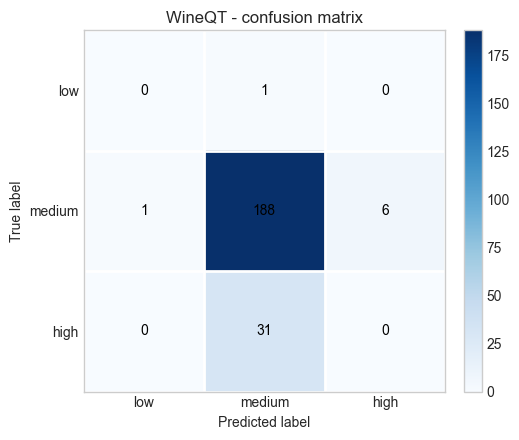

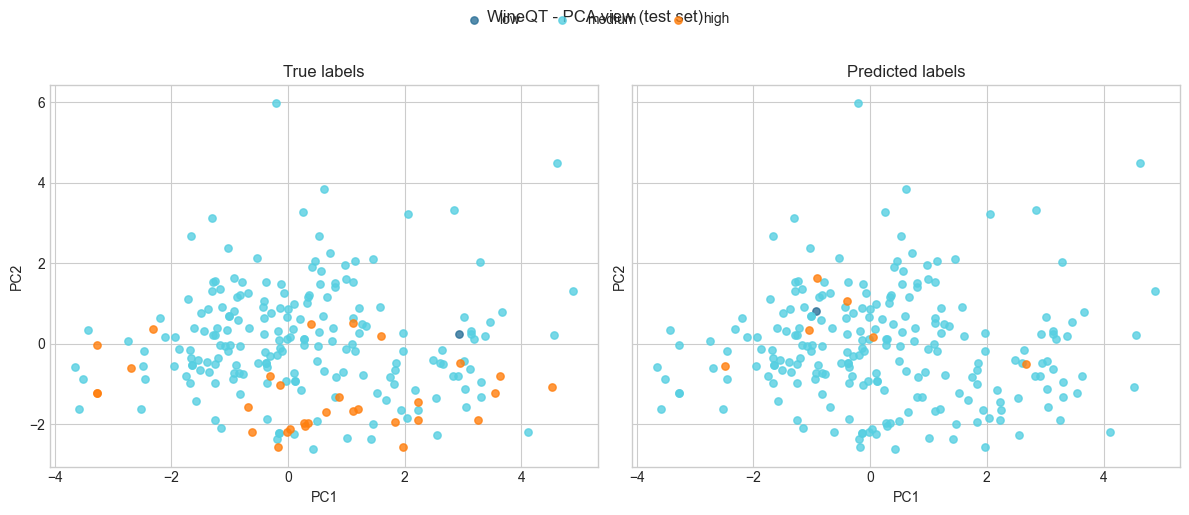

In [30]:
labels = ["low", "medium", "high"]
cm_dict = confusion_matrix(yw_test, yw_pred, classes=labels)
cm = np.array([[cm_dict[true_label][pred_label] for pred_label in labels] for true_label in labels])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
image = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.set_title("WineQT - confusion matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.grid(False)
ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.set_ylim(len(labels) - 0.5, -0.5)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

pca = PCA(n_component=2)
pca.fit(np.asarray(Xw_train_scaled))
Xw_test_2d = pca.transform(np.asarray(Xw_test_scaled))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
colors = {"low": "#2a6f97", "medium": "#56cfe1", "high": "#ff7f0e"}
for cls in labels:
    mask_true = np.asarray(yw_test) == cls
    mask_pred = np.asarray(yw_pred) == cls
    axes[0].scatter(Xw_test_2d[mask_true, 0], Xw_test_2d[mask_true, 1], s=28, alpha=0.8, color=colors[cls], label=str(cls))
    axes[1].scatter(Xw_test_2d[mask_pred, 0], Xw_test_2d[mask_pred, 1], s=28, alpha=0.8, color=colors[cls], label=str(cls))

axes[0].set_title("True labels")
axes[1].set_title("Predicted labels")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("WineQT - PCA view (test set)", y=1.02)
plt.tight_layout()
plt.show()